# Comparison of the BLS signal functions

SpinWaveToolkit calculates the BLS signal using two formalisms, each with the laser fields given either in real space (focal fields) or in reciprocal space (pupil fields):

| | focal fields | pupil fields |
|---|---|---|
| reciprocity theorem (RT) | `get_signal_RT_focal`, `get_signal_RT_focal_3d` | `get_signal_RT_pupil` |
| Green functions (GF) | `get_signal_GF_focal` | `get_signal_GF_pupil` |

This example calculates the spectrum of thermal and coherent magnons in a 30 nm thick NiFe layer with all of them, using the same susceptibility and laser fields.

Source publications:
- RT: Krčma et al., *Science Advances* **11**, eady8833 (2025). DOI: [10.1126/sciadv.ady8833](https://doi.org/10.1126/sciadv.ady8833)
- GF: Wojewoda et al., *Physical Review B* **110**, 224428 (2024). DOI: [10.1103/PhysRevB.110.224428](https://doi.org/10.1103/PhysRevB.110.224428)

### 1. Parameters

In [66]:
from time import perf_counter
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import SpinWaveToolkit as SWT

warnings.filterwarnings("ignore", message=".*experimental function.*")

# Magnetic layer
Bext = 50e-3            # (T) external field
theta = np.pi / 2       # (rad) out-of-plane angle of magnetization (in-plane)
phi0 = np.pi / 2        # (rad) in-plane angle of magnetization wrt. x axis
d_layer = 30e-9         # (m) layer thickness
material = SWT.NiFe
Nf = 101                # number of frequency points
fmin, fmax = 1e9, 35e9  # (Hz) frequency range

# Optics
NA = 0.75               # numerical aperture
wavelength = 532e-9     # (m)
f0 = 10                 # filling factor
focal_length = 1e-3     # (m)

# k-space grid: symmetric with an odd number of points (k = 0 on the grid)
# and reaching 2*k0*NA = 17.7 rad/um, where magnons can still scatter light into the NA
k_max = 18e6            # (rad/m)
Nk = 121

### 2. Dynamic susceptibility

The Bloch functions of the two lowest modes (n = 0, 1) are calculated for the whole k-space grid at once by passing flattened arrays of wavenumbers and propagation angles to `SingleLayer`.  `GetBlochFunction` returns them on a frequency axis common to all wavevectors, so they are interpolated onto our frequency axis in one step.  The static magnetization is along *y*, so the dynamic components are `mx` and `mz`, and the linear magneto-optic susceptibility is constructed with `mo_linear`.

In [67]:
t0 = perf_counter()
kx = ky = np.linspace(-k_max, k_max, Nk)
KX, KY = np.meshgrid(kx, ky, indexing="ij")
K = np.hypot(KX, KY)
K[K == 0] = 1.0  # avoid k = 0 in the dispersion model
PHI = SWT.wrapAngle(np.arctan2(KY, KX) + phi0)  # angle between k and magnetization
w = 2 * np.pi * np.linspace(fmin, fmax, Nf)  # (rad/s)

model = SWT.SingleLayer(Bext=Bext, kxi=K.ravel(), theta=theta, phi=PHI.ravel(),
                        d=d_layer, material=material)
Bloch = np.zeros((Nf, Nk, Nk))
for n in (0, 1):
    wn, bf = model.GetBlochFunction(n=n, Nf=Nf)  # bf has shape (Nf, Nk*Nk)
    Bloch += interp1d(wn, bf, axis=0, bounds_error=False, fill_value=0)(w).reshape(Nf, Nk, Nk)

chi = SWT.bls.susceptibilities.mo_linear([Bloch, np.zeros_like(Bloch), -1j * Bloch])
print(f"Susceptibility with shape {chi.shape} prepared in {perf_counter() - t0:.2f} s")

Susceptibility with shape (3, 3, 101, 121, 121) prepared in 0.29 s


### 3. Laser fields

The incident beam is linearly polarized along *x* and the signal is detected with crossed polarization (along *y*).  The RT functions use the field of the incident beam and the "virtual" field of the detection path (rotated by 90°), the GF functions only the incident field and an output analyzer at 90°.

In [68]:
objective = SWT.bls.ObjectiveLens(NA=NA, wavelength=wavelength, f0=f0, f=focal_length)

# focal fields in real space
t0 = perf_counter()
x, y, *Ei_focal = objective.getFocalField(z=0, rho_max=10e-6, N=121)
Ej_focal = SWT.rotate_field(Ei_focal, x, y, 90)
print(f"Focal fields with shape {Ei_focal[0].shape} prepared in {(perf_counter() - t0)*1e3:.1f} ms")

# pupil fields on the k-space grid of the susceptibility
t0 = perf_counter()
Ei_pupil = objective.getPupilField(0, KX, KY)
Ej_pupil = objective.getPupilField(0, KX, KY, pol_angle=90)
print(f"Pupil fields with shape {Ei_pupil[0].shape} prepared in {(perf_counter() - t0)*1e3:.1f} ms")

# parameters of the GF functions: layer stack (air, NiFe, substrate) and detection
gf_params = dict(
    DF=[1, -8.1653 + 15.348j, 17.237 + 0.43004j],  # dielectric functions
    PM=[1, 1, 1],                                  # permeabilities
    d=[d_layer],                                   # thicknesses of the inner layers
    NA=NA, wavelength=wavelength, collectionSpot=0.5e-6, focalLength=focal_length,
    output_analyzer="linear", output_analyzer_angle_deg=90,
)

Focal fields with shape (121, 121) prepared in 33.7 ms
Pupil fields with shape (121, 121) prepared in 1.5 ms


### 4. BLS signal from all functions

In [69]:
bls = SWT.bls


def all_signals(coherent_exc):
    # BLS spectra and calculation times of all signal functions
    calls = {
        "RT focal": lambda: bls.get_signal_RT_focal(
            (x, y), Ei_focal, Ej_focal, (kx, ky), chi, coherent_exc=coherent_exc)[0],
        "RT focal 3D": lambda: bls.get_signal_RT_focal_3d(
            (x, y), Ei_focal, Ej_focal, (kx, ky), chi, coherent_exc=coherent_exc)[0],
        "RT pupil": lambda: bls.get_signal_RT_pupil(
            (kx, ky), Ei_pupil, Ej_pupil, chi, coherent_exc=coherent_exc)[0],
        "GF focal": lambda: bls.get_signal_GF_focal(
            (x, y), Ei_focal, (kx, ky), chi, coherent_exc=coherent_exc, **gf_params),
        "GF pupil": lambda: bls.get_signal_GF_pupil(
            (kx, ky), Ei_pupil, chi, coherent_exc=coherent_exc, **gf_params),
    }
    results = {}
    for name, f in calls.items():
        t0 = perf_counter()
        sigma = np.real(f())
        results[name] = (sigma, perf_counter() - t0)
    return results


signals = {"thermal": all_signals(False), "coherent": all_signals(True)}

### 5. Results

Within each formalism, the focal and pupil variants should give the same absolute signal, so both are normalized to the maximum of the pupil variant.  The RT and GF formalisms treat the optics of the sample differently (see the source publications) and have different absolute scales, so they are compared only after normalization.

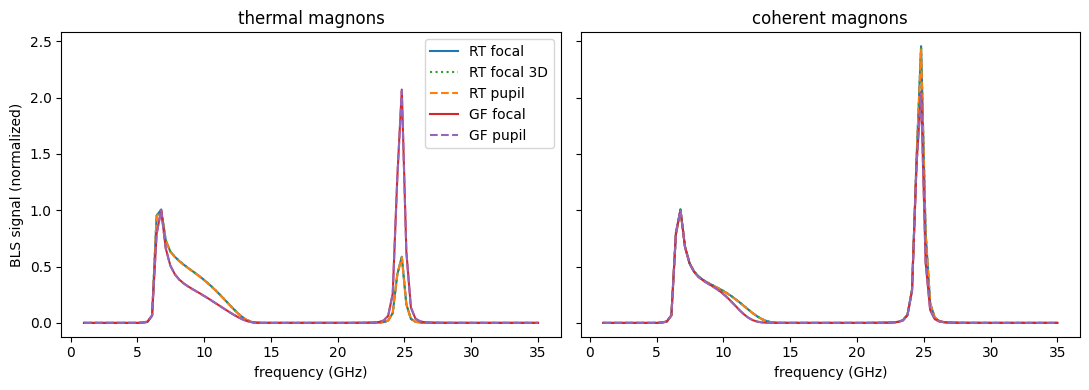

              time (s)   max. rel. difference from the pupil variant
thermal
  RT focal       0.080                                       7.7e-03
  RT focal 3D    0.074                                       7.7e-03
  RT pupil       0.085                                       0.0e+00
  GF focal       0.909                                       4.6e-03
  GF pupil       0.885                                       0.0e+00
coherent
  RT focal       0.046                                       8.5e-03
  RT focal 3D    0.050                                       8.5e-03
  RT pupil       0.052                                       0.0e+00
  GF focal       0.943                                       4.8e-03
  GF pupil       0.896                                       0.0e+00


In [70]:
f_GHz = w / (2 * np.pi * 1e9)
styles = {"RT focal": ("C0", "-"), "RT focal 3D": ("C2", ":"), "RT pupil": ("C1", "--"),
          "GF focal": ("C3", "-"), "GF pupil": ("C4", "--")}

fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (kind, results) in zip(axs, signals.items()):
    for name, (sigma, _) in results.items():
        norm = results[name[:2] + " pupil"][0][:Nf//2].max()  # same norm within a formalism and n=0
        c, ls = styles[name]
        ax.plot(f_GHz, sigma / norm, ls, c=c, lw=1.5, label=name)
    ax.set_title(f"{kind} magnons")
    ax.set_xlabel("frequency (GHz)")
axs[0].set_ylabel("BLS signal (normalized)")
axs[0].legend()
plt.tight_layout()
plt.show()

print(f"{'':12s} {'time (s)':>9s} {'max. rel. difference from the pupil variant':>45s}")
for kind, results in signals.items():
    print(kind)
    for name, (sigma, t) in results.items():
        ref = results[name[:2] + " pupil"][0]
        print(f"  {name:12s} {t:7.3f} {np.abs(sigma - ref).max() / ref.max():45.1e}")

The focal and pupil variants of each formalism agree to better than 1 % (`get_signal_RT_focal_3d` with a single depth is identical to `get_signal_RT_focal`).  The pupil variants are slightly faster and do not need the focal fields, whose calculation is usually the slowest part of the input preparation.  The two formalisms give the same peak frequencies, but different relative heights of the peaks of the n = 0 (broad, dispersive) and n = 1 (narrow) modes, especially for thermal magnons.

*(Note: The relative amplitude of the peaks of different modes may not match the experiment, since it depends on many parameters. If needed, normalize the signal to the respective peaks.)*

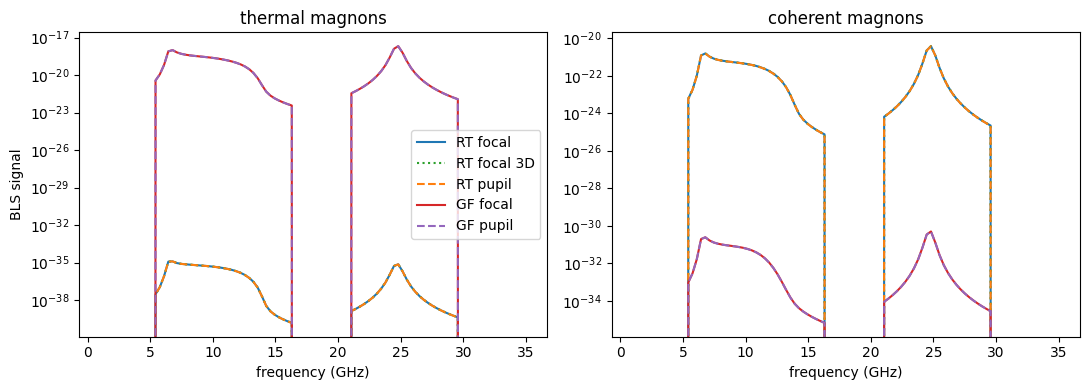

In [71]:
# illustration of raw BLS signal amplitudes
f_GHz = w / (2 * np.pi * 1e9)
styles = {"RT focal": ("C0", "-"), "RT focal 3D": ("C2", ":"), "RT pupil": ("C1", "--"),
          "GF focal": ("C3", "-"), "GF pupil": ("C4", "--")}

fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, (kind, results) in zip(axs, signals.items()):
    for name, (sigma, _) in results.items():
        norm = results[name[:2] + " pupil"][0].max()  # same normalization within a formalism
        c, ls = styles[name]
        # ax.plot(f_GHz, sigma / norm, ls, c=c, lw=1.5, label=name)
        ax.plot(f_GHz, sigma, ls, c=c, lw=1.5, label=name)
    ax.set_title(f"{kind} magnons")
    ax.set_xlabel("frequency (GHz)")
    ax.set_yscale("log")
axs[0].set_ylabel("BLS signal")
axs[0].legend()
plt.tight_layout()
plt.show()